In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

from pangal.pangal import PanGal
from pangal.pfitter import PFitter

from build_boissier import truncated_boissier_sfh, truncated_boissier_sed, build_boissier_SEDs, load_spectrum_models_from_fits

import warnings
warnings.filterwarnings("ignore")

In [2]:
specs = load_spectrum_models_from_fits(filename='V_160_R_7.fit')

In [3]:
specs[0].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   12 / length of dimension 1                          
NAXIS2  =                16688 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    3 / number of table fields                         
TTYPE1  = 'FLUX    '                                                            
TFORM1  = 'E       '                                                            
TTYPE2  = 'FLUX_YOUNG'                                                          
TFORM2  = 'E       '                                                            
TTYPE3  = 'FLUX_OLD'        

In [4]:
fitter = PFitter(specs,
                 model_pars=['Q_AGE','TAU_Q','BURST','METAL'],
                )

Initializing PFitter object
   Model parameters: Q_AGE, TAU_Q, BURST, METAL

 Pre-computed model grid:
   - Q_AGE: 19 values, min=10, max=1000
   - TAU_Q: 15 values, min=2, max=1000
   - BURST: 6 values, min=0.0, max=100.0
   - METAL: 5 values, min=0.008, max=0.03


Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75   2.8125 2.875  2.9375 3.     3.0625 3

In [5]:
mock_specs = []
for v_disp in [50,60,70,100,150,200]: #100,1000
    

    mock_spec = fitter.synthetic_spectrum(
                multi_component=True,
                Q_AGE=190,
                TAU_Q=50,
                BURST=0,
                METAL=0.017,
                fesc=0.5,
                av=0.2,
                av_ext= 0.0,
                alpha=3.5,
                m_star=9.2,
                ion_gas=-0.94,
                age_gas=6,
                redshift=0.02,
                vel_sys=0.01,
                sigma_vel=v_disp,
                dl=104,  # Luminosity distance in Mpc (assumed)
            )
    mock_specs.append(mock_spec)



array([2.80e+00, 3.25e+00, 3.70e+00, ..., 8.00e+05, 8.00e+05, 8.00e+05],
      dtype=float32)

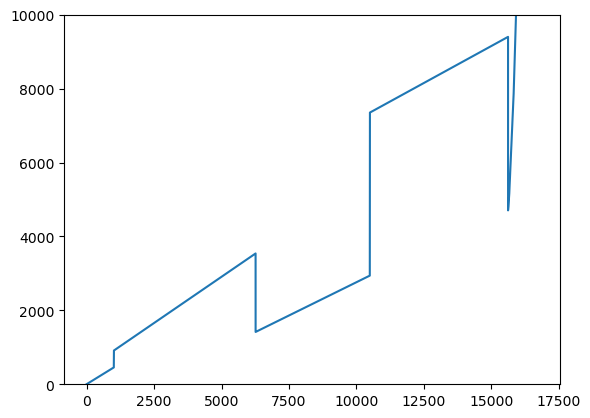

In [6]:
mock_specs[0].res_delta_lambda/fitter.model_wl
plt.plot(fitter.model_res)
plt.ylim(0,10000)
fitter.model_res

In [7]:
from pangal.data.spectral_lines import spectral_lines


In [8]:
spectral_lines

{'Lya': 1215.67,
 'Hd': 4102,
 'Hg': 4340,
 'Hb': 4861,
 'Ha': 6563,
 'He II 4686': 4686,
 'He I 4471': 4471,
 'He I 5876': 5876,
 '[O II] 3727': 3727,
 '[O III] 4959': 4959,
 '[O III] 5007': 5007,
 '[N II] 6548': 6548,
 '[N II] 6583': 6583,
 '[S II] 6716': 6716,
 '[S II] 6731': 6731,
 '[Ar III] 7136': 7136,
 '[Fe II] 5159': 5159,
 '[Fe I] 4383': 4383,
 '[Fe I] 5270': 5270,
 '[Fe I] 5335': 5335,
 '[Fe VII] 6087': 6087,
 '[Ca II] 8498': 8498,
 '[Ca II] 8542': 8542,
 '[Ca II] 8662': 8662,
 'Ca H': 3968,
 'Ca K': 3934,
 'Mg I 5167': 5167,
 'Mg I 5172': 5172,
 'Mg I 5183': 5183,
 'Na I D1': 5890,
 'Na I D2': 5896,
 'G-band (CH) 4300': 4300,
 'CN Band 4215': 4215}

In [16]:
phot_points.wavelength

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 phot_points.wavelength                                                                       │
│   2                                                                                              │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
AttributeError: 'PhotometryTable' object has no attribute 'wavelength'

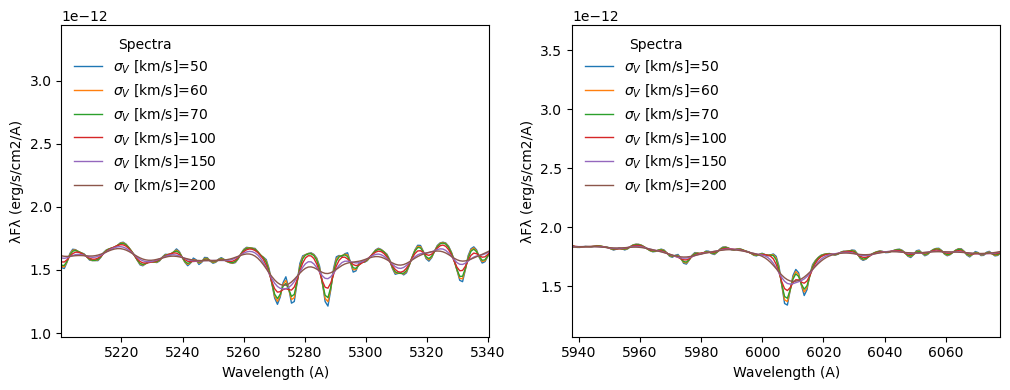

In [17]:
bands=['galex_fuv','galex_nuv','sdss_u','sdss_g','sdss_r','sdss_i','sdss_z',
       'spitzer_irac_1','spitzer_irac_2','spitzer_irac_3','spitzer_irac_4',
      'herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um']


phot_points = mock_spec.get_phot(bands=bands,units='mJy')

for b in bands: 
    value, error = phot_points.data[b]
    phot_points.data[b] = (value+0.1*value, 0.1 * value)


legend = {'SIGMA_V': "$\sigma_V$ [km/s]"}

mock_specs[0].plot(spectra=mock_specs,per_wavelength=True,show_phot_legend=False, #phot_points=phot_points, #synth_phot_points=False,phot_points=phot_points,
              winf=1000,wsup=2e6,show_all_spectral_lines=True,zoom_on_line=['Mg I 5167','Na I D1'],spec_legend=legend)


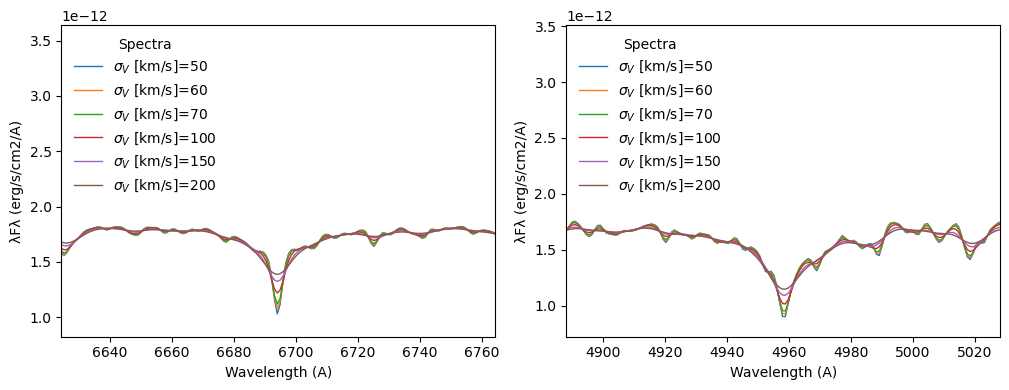

In [10]:
mock_specs[0].plot(spectra=mock_specs,per_wavelength=True,show_phot_legend=True,synth_phot_points=bands,phot_points=phot_points,
              winf=1000,wsup=2e6,show_H_lines=True,zoom_on_line=['Ha','Hb'],spec_legend=legend)

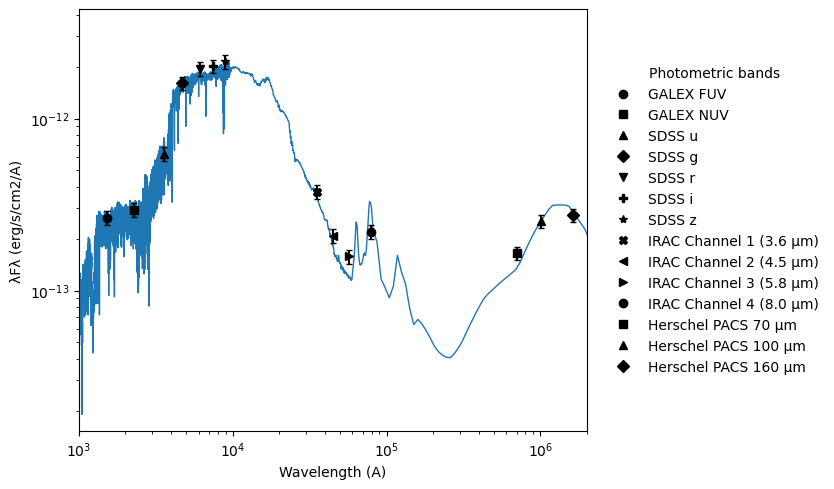

In [12]:
mock_specs[0].plot(figsize=(10,5),spectra=mock_specs[0],per_wavelength=True,show_phot_legend=True,phot_points=phot_points,
              winf=1000,wsup=2e6,show_H_lines=False,spec_legend=legend)
#synth_phot_points=bands


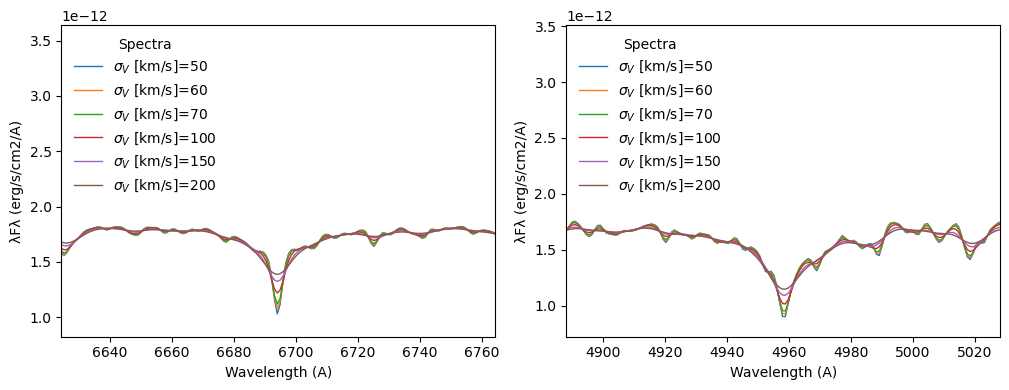

In [7]:
bands=['galex_fuv','galex_nuv','sdss_u','sdss_g','sdss_r','sdss_i','sdss_z',
       'spitzer_irac_1','spitzer_irac_2','spitzer_irac_3','spitzer_irac_4',
      'herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um']


phot_points = mock_spec.get_phot(bands=bands,units='mJy')

for b in bands: 
    value, error = phot_points.data[b]
    phot_points.data[b] = (value+0.1*value, 0.1 * value)


legend = {'SIGMA_V': "$\sigma_V$ [km/s]"}

mock_specs[0].plot(spectra=mock_specs,per_wavelength=True,show_phot_legend=True,synth_phot_points=bands,phot_points=phot_points,
              winf=1000,wsup=2e6,show_H_lines=True,zoom_on_line=['Ha','Hb'],spec_legend=legend)


In [13]:
c_kms = 3e5  # km/s
sigma_v = 10.0  # km/s (example)
lam0 = 1e4  # Å, adjust to your line
sigma_lambda = lam0 * (sigma_v / c_kms)
print("sigma_lambda (Å):", sigma_lambda)
print("delta_lambda (median):", np.median(np.diff(mock_specs[0].wl)))  # your wl array

sigma_lambda (Å): 0.33333333333333337
delta_lambda (median): 0.5099999999999909


In [14]:
phot_points.print()

,Value,Error,SNR
Band,,,
galex_fuv,0.013998,0.001273,11.0
galex_nuv,0.023151,0.002105,11.0
sdss_u,0.075482,0.006862,11.0
sdss_g,0.252535,0.022958,11.0
sdss_r,0.401925,0.036539,11.0
sdss_i,0.520591,0.047326,11.0
sdss_z,0.643577,0.058507,11.0
spitzer_irac_1,0.443798,0.040345,11.0
spitzer_irac_2,0.313171,0.028470,11.0


In [15]:
phot_points.data

{'galex_fuv': (0.013998123579305393, 0.001272556689027763),
 'galex_nuv': (0.023150654866964868, 0.002104604987905897),
 'sdss_u': (0.07548222461820914, 0.006862020419837195),
 'sdss_g': (0.25253459367734504, 0.022957690334304098),
 'sdss_r': (0.40192542606916265, 0.036538675097196605),
 'sdss_i': (0.5205909620841069, 0.04732645109855518),
 'sdss_z': (0.6435773713292605, 0.05850703375720551),
 'spitzer_irac_1': (0.4437984238767272, 0.04034531126152066),
 'spitzer_irac_2': (0.3131714478365094, 0.028470131621500857),
 'spitzer_irac_3': (0.3031688626507421, 0.027560805695522012),
 'spitzer_irac_4': (0.5859101386329896, 0.053264558057544514),
 'herschel_pacs_70um': (3.6786022043896724, 0.33441838221724296),
 'herschel_pacs_100um': (9.224966752482066, 0.8386333411347334),
 'herschel_pacs_160um': (17.22156965262473, 1.5655972411477028)}

In [16]:
#custom_prior = {
#    'av':     {'type':'uniform', 'low':0.0,    'high':1.2},
#    'alpha':  {'type':'uniform', 'low':1.5,    'high':3.5}
#}

In [8]:
results_with_herschel = fitter.run_fit(phot=phot_points, 
                         bands=bands, 
                         fix_pars={'ion_gas':-3.94,'age_gas':13,
                                   'fesc':0.5,'m_star':9.2,'av_ext':0.0,
                                   'av':1.2,'alpha':3.5,"vel_sys":0,"sigma_vel":0,
                                  'BURST':0,'METAL':0.017}, 
                        nlive=100,
                        dlogz=0.1,
                        )


Using the following photometric filters: galex_fuv, galex_nuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_100um, herschel_pacs_160um
Redshift not provided; set to 0.

Priors:
  - Q_AGE: Uniform(10, 1000)
  - TAU_Q: Uniform(2, 1000)
Initializing live points


1381it [00:16, 81.67it/s, +100 | bound: 16 | nc: 1 | ncall: 6063 | eff(%): 24.836 | loglstar:   -inf < -515.488 <    inf | logz: -526.895 +/-  0.310 | dlogz:  0.001 >  0.100]


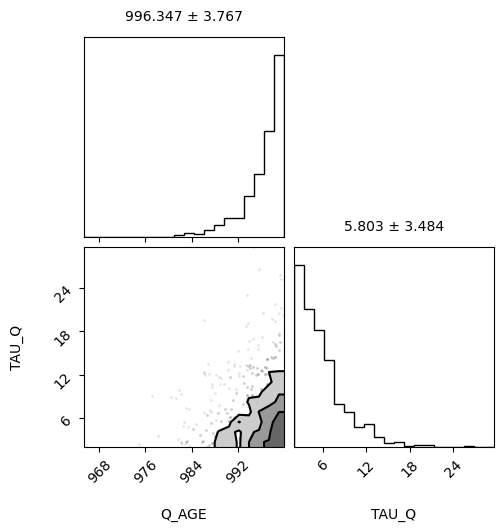

In [10]:
results_with_herschel.cornerplot()

In [11]:
results_with_herschel.best_model()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 results_with_herschel.best_model()                                                           │
│   2                                                                                              │
│                                                                                                  │
│ /home/utente/Desktop/Pangal/pangal/run.py:197 in best_model                                      │
│                                                                                                  │
│   194 │   │   │   │   idx += 1                                                                   │
│   195 │   │                                                                                      │
│   196 │   │   # Build synthetic spectrum                                                         │
│ ❱ 197 │   │   synth_spec = self.pfitter.synthetic_spectrum(**best_params,                        │
│   198 │   │   │   │   │   │   │   │   │   │   │    redshift=0, dl=100,                           │
│   199 │   │   │   │   │   │   │   │   │   │   │    observed_spectrum_resolution=getattr(self,    │
│   200                                                                                            │
│                                                                                                  │
│ /home/utente/Desktop/Pangal/pangal/pfitter.py:475 in synthetic_spectrum                          │
│                                                                                                  │
│   472 │   │   """                                                                                │
│   473 │   │                                                                                      │
│   474 │   │   # --- Stellar population spectra ---                                               │
│ ❱ 475 │   │   young_stellar_spec = self.interp_young_flux(**kwargs)                              │
│   476 │   │   old_stellar_spec   = self.interp_old_flux(**kwargs)                                │
│   477 │   │                                                                                      │
│   478 │   │   # Resample to model wavelength grid                                                │
│                                                                                                  │
│ /home/utente/Desktop/Pangal/pangal/pfitter_utils.py:266 in interp_flux_young                     │
│                                                                                                  │
│   263 │   interp_old = RegularGridInterpolator(points=grid_axes, values=flux_old_grid, bounds_   │
│   264 │                                                                                          │
│   265 │   def interp_flux_young(**kwargs):                                                       │
│ ❱ 266 │   │   x = [kwargs[name] for name in param_names]                                         │
│   267 │   │   return interp_young(x)[0]                                                          │
│   268 │                                                                                          │
│   269 │   def interp_flux_old(**kwargs):                                                         │
│                                                                                                  │
│ /home/utente/Desktop/Pangal/pangal/pfitter_utils.py:266 in <listcomp>                            │
│                                                                                                  │
│   263 │   interp_old = RegularGridInterpolator(points=grid_axes, values=flux_old_grid, bounds_   │
│   264 │                                                    

In [9]:
fitter.cornerplot(results)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 fitter.cornerplot(results)                                                                   │
│   2                                                                                              │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
AttributeError: 'PFitter' object has no attribute 'cornerplot'

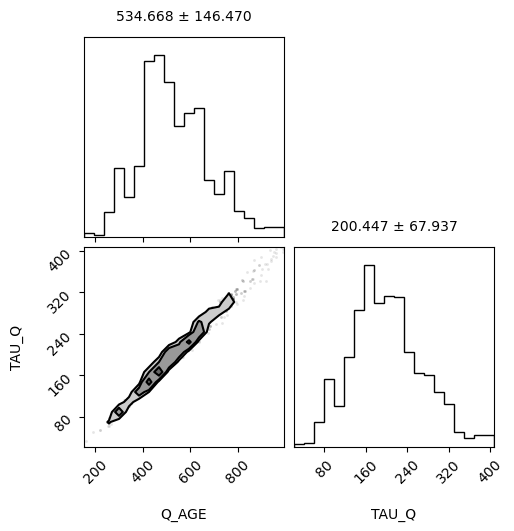

In [21]:
fitter.cornerplot(results)

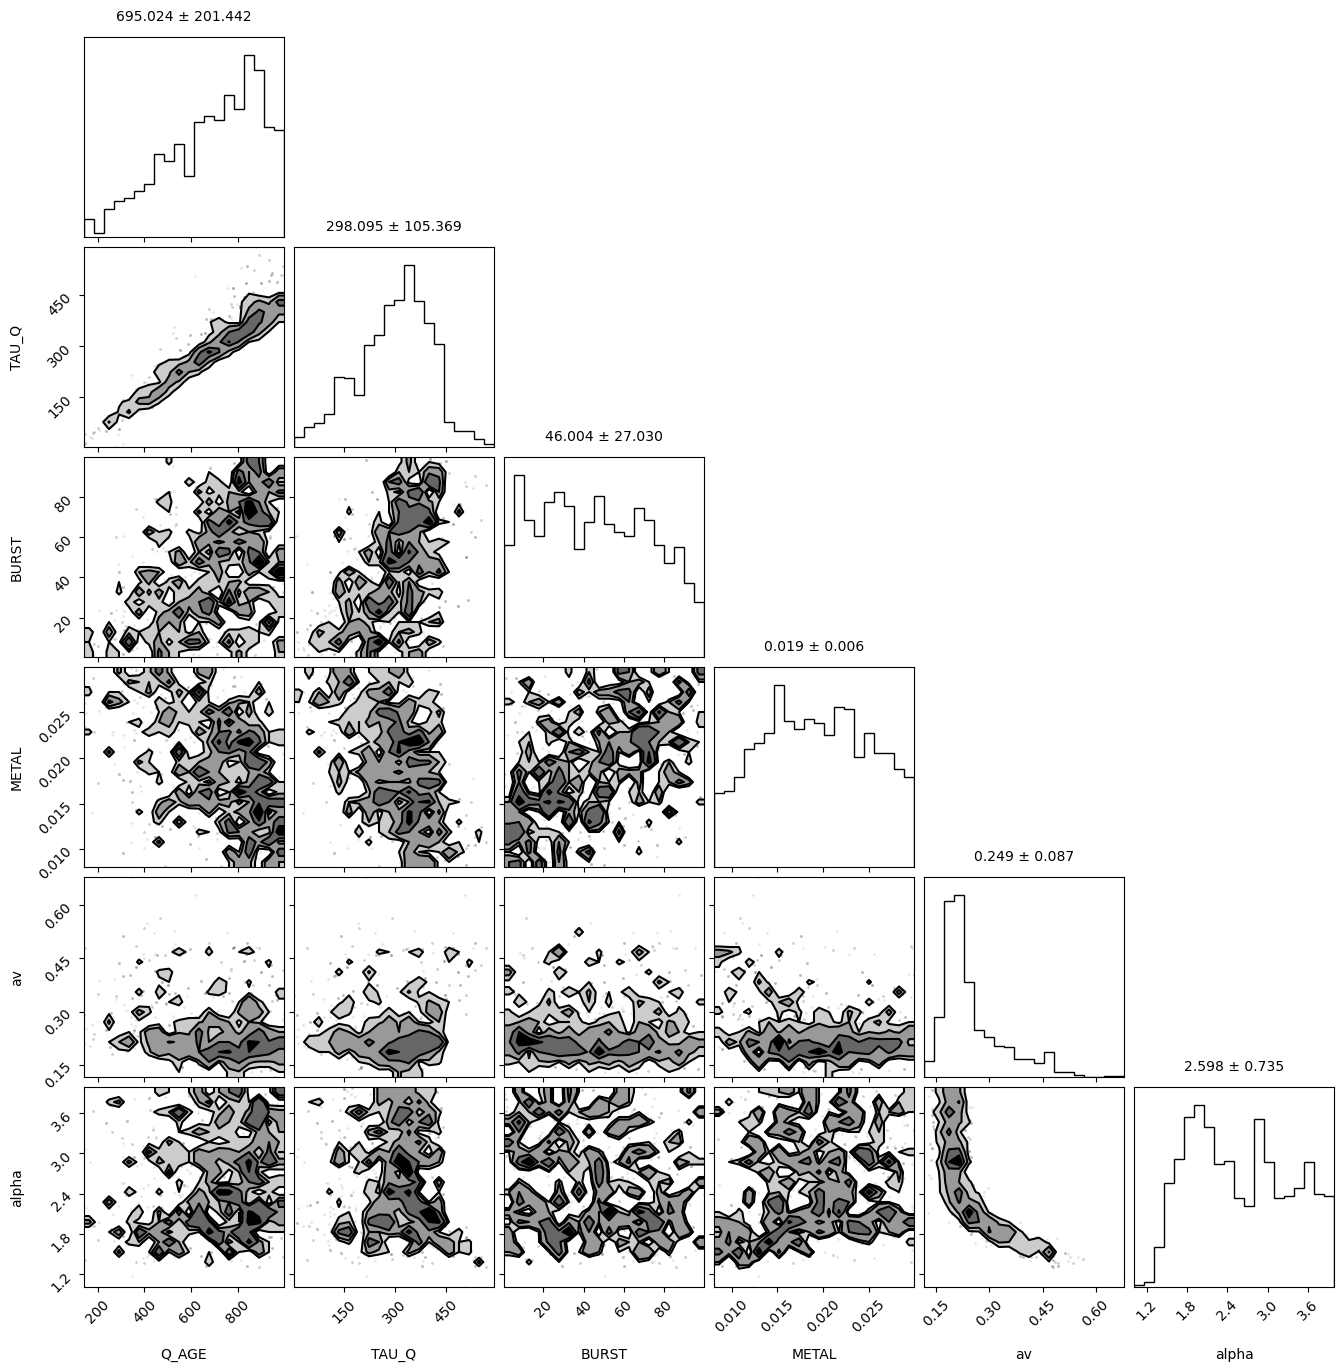

In [10]:
fitter.cornerplot(results)

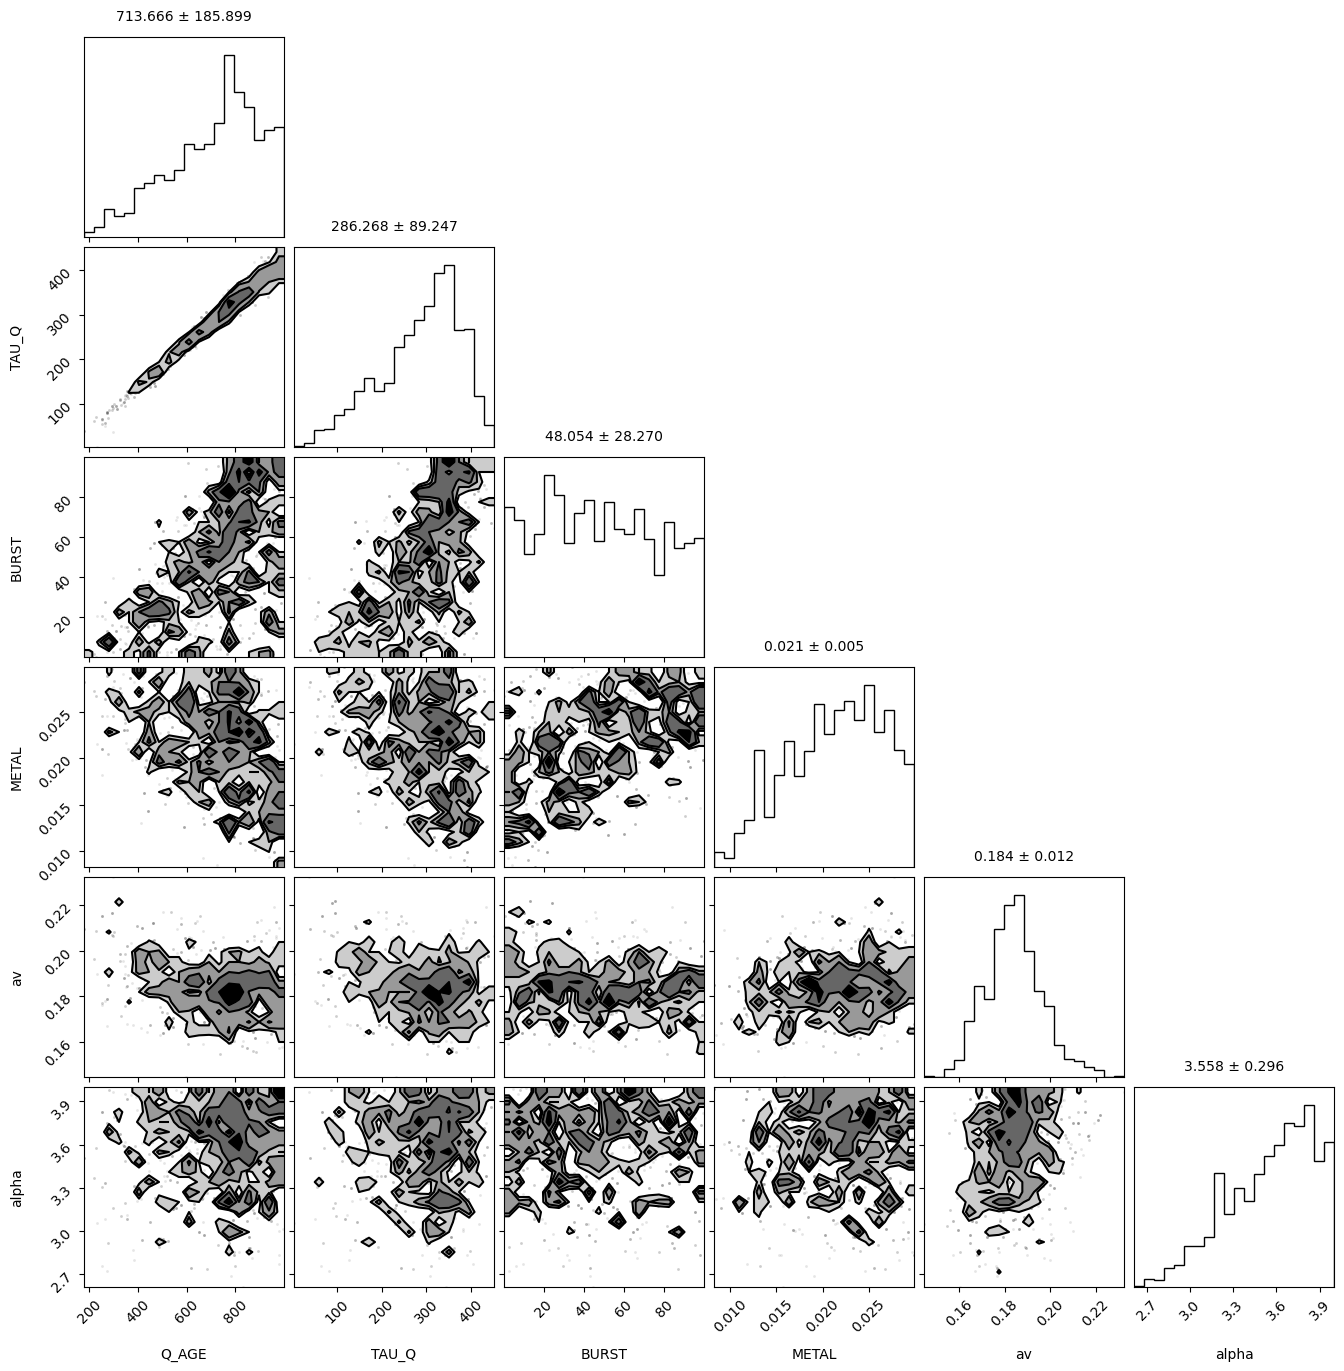

In [18]:
fitter.cornerplot(results_with_herschel)

In [30]:
fit_spec_2 = fitter.synthetic_spectrum(
            multi_component=True,
            Q_AGE=800,
            TAU_Q=320,
            #BURST=0,
            #METAL=0.017,
            fesc=0.5,
            av=1.2,
            av_ext= 0.0,
            alpha=3.5,
            m_star=9.2,
            ion_gas=-3.94,
            age_gas=13,
            redshift=0.02,
            dl=104,  # Luminosity distance in Mpc (assumed)
        )

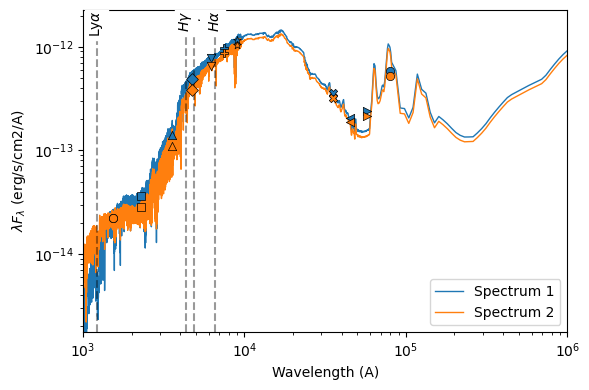

In [31]:
mock_spec.plot(spectra=[mock_spec,fit_spec_2],per_wavelength=True,phot_points=bands,phot_legend=True,
              winf=1000,wsup=1e6,show_H_lines=True)